# March Machine Learning Mania 2026 — Model
Clean, self-contained notebook for training and generating a submission.

**Pipeline:**
1. Load data
2. Walk-forward cross-validation (leak-free)
3. Train final ensemble on all available data
4. Generate and save submission

## 1 · Imports & Config

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

from pipeline import (
    MODEL_FEATURE_COLS,
    XGB_PARAMS, LR_PARAMS,
    XGB_BLEND_WEIGHT, LR_BLEND_WEIGHT,
    build_elo_ratings,
    build_team_features,
    build_matchup_dataset,
    build_weighted_train_test,
    train_ensemble,
    predict_ensemble,
    tune_hyperparameters,
    get_feature_importances,
    generate_2026_submission,
    generate_combined_submission,
    cross_validate,
)

# ── Config ───────────────────────────────────────────────────────────────────
DATA_DIR      = '/Users/loganheydt/Desktop/Data/GitHub/Kaggle_competitions/March_Machine_Learning_Mania_2026/data'
OUTPUT_DIR    = '../submissions'
SEASON_CUTOFF = 2003   # discard seasons before this year (sparse detailed stats)
RUN_TUNING    = False  # set True to run Optuna hyperparameter search (slow)

## 2 · Load Data

In [2]:
# ── Men's data ───────────────────────────────────────────────────────────────
m_regular = pd.read_csv(f'{DATA_DIR}/MRegularSeasonDetailedResults.csv')
m_tourney  = pd.read_csv(f'{DATA_DIR}/MNCAATourneyDetailedResults.csv')
m_seeds    = pd.read_csv(f'{DATA_DIR}/MNCAATourneySeeds.csv')

# ── Women's data ─────────────────────────────────────────────────────────────
w_regular = pd.read_csv(f'{DATA_DIR}/WRegularSeasonDetailedResults.csv')
w_tourney  = pd.read_csv(f'{DATA_DIR}/WNCAATourneyDetailedResults.csv')
w_seeds    = pd.read_csv(f'{DATA_DIR}/WNCAATourneySeeds.csv')

# ── Massey Ordinals (men's only) ─────────────────────────────────────────────
massey = pd.read_csv(f'{DATA_DIR}/MMasseyOrdinals.csv')

# ── Submission template ───────────────────────────────────────────────────────
sample_sub = pd.read_csv(f'{DATA_DIR}/SampleSubmissionStage2.csv')

# Drop seasons with incomplete box-score data
for df in [m_regular, m_tourney, m_seeds, w_regular, w_tourney, w_seeds]:
    df.drop(df[df['Season'] < SEASON_CUTOFF].index, inplace=True)

print(f"Men's   regular : {len(m_regular):,}  |  tourney : {len(m_tourney):,}")
print(f"Women's regular : {len(w_regular):,}  |  tourney : {len(w_tourney):,}")
print(f"Massey rows     : {len(massey):,}  |  systems : {massey['SystemName'].nunique()}")
print(f"Submission rows : {len(sample_sub):,}")

Men's   regular : 122,775  |  tourney : 1,449
Women's regular : 85,505  |  tourney : 961
Massey rows     : 5,761,702  |  systems : 196
Submission rows : 132,133


## 3 · Walk-Forward Cross-Validation

- Elo and season stats are computed once (no leakage).
- PCA and KMeans are **refit each fold** on training seasons only.
- Calibration uses the most recent training season as a held-out set.
- Tournament games are up-weighted 2× vs regular season games.

In [3]:
# CV is run on men's data; repeat separately for women's if needed
fold_results, fold_importances = cross_validate(
    regular_df=m_regular,
    tourney_df=m_tourney,
    seeds_df=m_seeds,
    model_feature_cols=MODEL_FEATURE_COLS,
    min_train_seasons=5,
    regular_weight=1.0,
    tourney_weight=2.0,
    verbose=True,
)

Fold  1 | Season 2008 | brier = 0.1680 | log_loss = 0.5035
Fold  2 | Season 2009 | brier = 0.1573 | log_loss = 0.4712
Fold  3 | Season 2010 | brier = 0.1915 | log_loss = 0.5620
Fold  4 | Season 2011 | brier = 0.2404 | log_loss = 0.6774
Fold  5 | Season 2012 | brier = 0.1917 | log_loss = 0.5681
Fold  6 | Season 2013 | brier = 0.2043 | log_loss = 0.6019
Fold  7 | Season 2014 | brier = 0.2023 | log_loss = 0.5861
Fold  8 | Season 2015 | brier = 0.1777 | log_loss = 0.5324
Fold  9 | Season 2016 | brier = 0.1931 | log_loss = 0.5703
Fold 10 | Season 2017 | brier = 0.1747 | log_loss = 0.5131
Fold 11 | Season 2018 | brier = 0.1999 | log_loss = 0.5910
Fold 12 | Season 2019 | brier = 0.1930 | log_loss = 0.5522
Fold 13 | Season 2021 | brier = 0.2296 | log_loss = 0.6524
Fold 14 | Season 2022 | brier = 0.2233 | log_loss = 0.6417
Fold 15 | Season 2023 | brier = 0.2238 | log_loss = 0.6425
Fold 16 | Season 2024 | brier = 0.2024 | log_loss = 0.5803
Fold 17 | Season 2025 | brier = 0.1471 | log_loss = 0.45

### 3a · Fold Results

In [4]:
fold_results

,fold,test_season,train_rows,test_rows,brier_score,log_loss
0,1,2008,47964,128,0.167953,0.503494
1,2,2009,58418,128,0.157333,0.471172
2,3,2010,69044,128,0.191516,0.561956
3,4,2011,79698,134,0.240365,0.677400
4,5,2012,90324,134,0.191656,0.568139
5,6,2013,100964,134,0.204296,0.601875
6,7,2014,111738,134,0.202296,0.586081
7,8,2015,122596,134,0.177717,0.532357
8,9,2016,133438,134,0.193144,0.570329
9,10,2017,144310,134,0.174735,0.513111


### 3b · CV Summary Statistics

Mean Brier score : 0.1953  (competition metric)
Std              : 0.0254
Min              : 0.1471  (season 2025)
Max              : 0.2404  (season 2011)

Mean log loss    : 0.5707


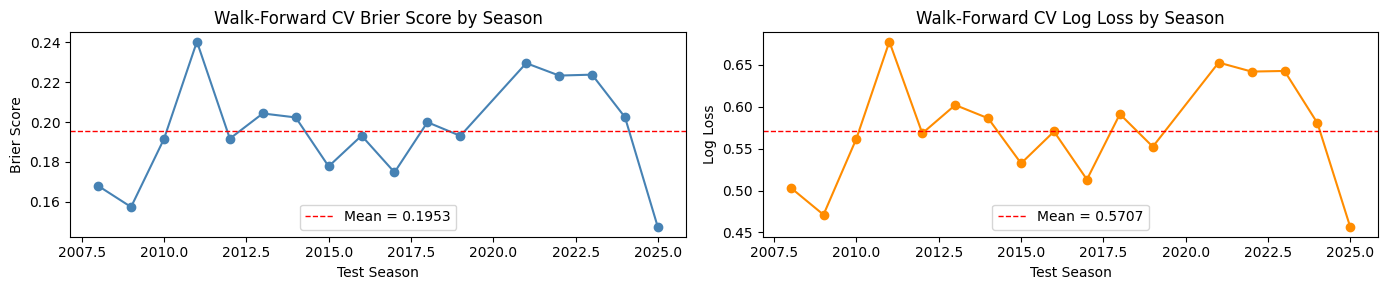

In [5]:
bs = fold_results['brier_score']
ll = fold_results['log_loss']
print(f'Mean Brier score : {bs.mean():.4f}  (competition metric)')
print(f'Std              : {bs.std():.4f}')
print(f'Min              : {bs.min():.4f}  (season {fold_results.loc[bs.idxmin(), "test_season"]})')
print(f'Max              : {bs.max():.4f}  (season {fold_results.loc[bs.idxmax(), "test_season"]})')
print(f'\nMean log loss    : {ll.mean():.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 3))

axes[0].plot(fold_results['test_season'], bs, marker='o', linewidth=1.5, color='steelblue')
axes[0].axhline(bs.mean(), linestyle='--', color='red', linewidth=1, label=f'Mean = {bs.mean():.4f}')
axes[0].set_xlabel('Test Season')
axes[0].set_ylabel('Brier Score')
axes[0].set_title('Walk-Forward CV Brier Score by Season')
axes[0].legend()

axes[1].plot(fold_results['test_season'], ll, marker='o', linewidth=1.5, color='darkorange')
axes[1].axhline(ll.mean(), linestyle='--', color='red', linewidth=1, label=f'Mean = {ll.mean():.4f}')
axes[1].set_xlabel('Test Season')
axes[1].set_ylabel('Log Loss')
axes[1].set_title('Walk-Forward CV Log Loss by Season')
axes[1].legend()

plt.tight_layout()
plt.show()

### 3c · Mean Feature Importances (XGBoost)

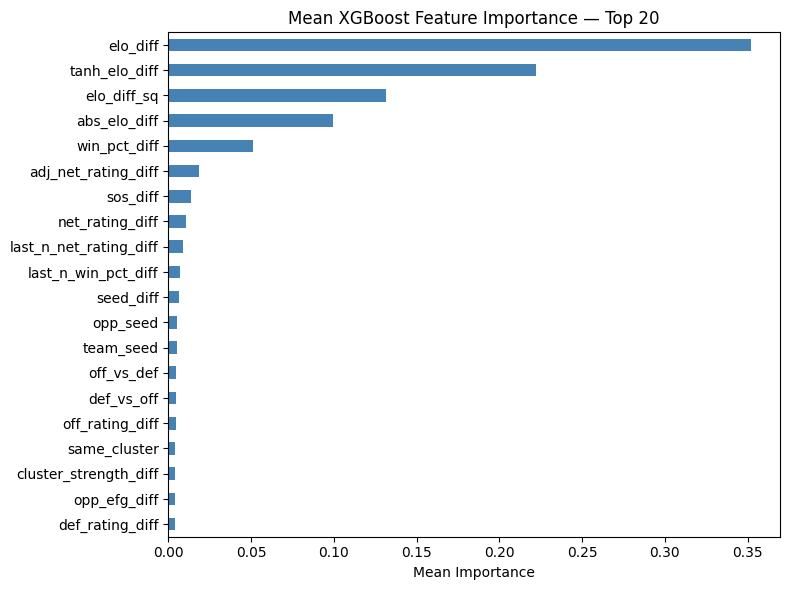

elo_diff                  0.352041
tanh_elo_diff             0.222384
elo_diff_sq               0.131314
abs_elo_diff              0.099253
win_pct_diff              0.050858
adj_net_rating_diff       0.018157
sos_diff                  0.013385
net_rating_diff           0.010633
last_n_net_rating_diff    0.008515
last_n_win_pct_diff       0.007234
seed_diff                 0.006210
opp_seed                  0.005437
team_seed                 0.005421
off_vs_def                0.004660
def_vs_off                0.004585
off_rating_diff           0.004478
same_cluster              0.004242
cluster_strength_diff     0.004179
opp_efg_diff              0.004144
def_rating_diff           0.004108


In [6]:
importance_df   = pd.concat(fold_importances, axis=1)
mean_importance = importance_df.mean(axis=1).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
mean_importance.head(20).sort_values().plot.barh(ax=ax, color='steelblue')
ax.set_title('Mean XGBoost Feature Importance — Top 20')
ax.set_xlabel('Mean Importance')
plt.tight_layout()
plt.show()

print(mean_importance.head(20).to_string())

## 4 · Final Model Training

Train on **all** regular season + tournament data.  
The most recent season is held out for Platt-scaling calibration.

### 4a · Build Elo Ratings

In [7]:
m_elo = build_elo_ratings(m_regular)
w_elo = build_elo_ratings(w_regular)

print(f"Men's   Elo rows : {len(m_elo):,}  |  range : {m_elo['elo'].min():.1f} – {m_elo['elo'].max():.1f}")
print(f"Women's Elo rows : {len(w_elo):,}  |  range : {w_elo['elo'].min():.1f} – {w_elo['elo'].max():.1f}")
m_elo.groupby('Season')['elo'].describe()[['mean', 'std', 'min', 'max']].tail(3)

Men's   Elo rows : 8,346  |  range : 897.8 – 2092.2
Women's Elo rows : 5,965  |  range : 897.0 – 2242.0


,mean,std,min,max
Season,,,,
2024,1495.117786,197.478785,996.736464,2006.820852
2025,1493.106374,201.815533,920.157306,1991.275404
2026,1480.396525,192.297105,953.416835,2012.515162


### 4b · Build Team Features (Stats + PCA + Clusters)

In [8]:
# Men's: pass massey_df to get ranking features
m_team_features, m_pca, m_kmeans = build_team_features(
    regular_df=m_regular,
    seeds_df=m_seeds,
    season_elo=m_elo,
    massey_df=massey,
)

# Women's: no Massey Ordinals file available for women's
w_team_features, w_pca, w_kmeans = build_team_features(
    regular_df=w_regular,
    seeds_df=w_seeds,
    season_elo=w_elo,
)

print(f"Men's   team-season rows : {len(m_team_features):,}  |  features : {m_team_features.shape[1]}")
print(f"Women's team-season rows : {len(w_team_features):,}  |  features : {w_team_features.shape[1]}")

massey_cols = [c for c in m_team_features.columns if c.startswith('massey')]
print(f"\nMassey features added ({len(massey_cols)}): {massey_cols}")

Men's   team-season rows : 8,346  |  features : 77
Women's team-season rows : 5,965  |  features : 68

Massey features added (9): ['massey_pom_rank', 'massey_sag_rank', 'massey_mor_rank', 'massey_col_rank', 'massey_dol_rank', 'massey_ap_rank', 'massey_mean_rank', 'massey_median_rank', 'massey_std_rank']


### 4c · Build Matchup Dataset

In [9]:
m_reg_matchups = build_matchup_dataset(m_regular, m_team_features)
m_trn_matchups = build_matchup_dataset(m_tourney,  m_team_features)
w_reg_matchups = build_matchup_dataset(w_regular, w_team_features)
w_trn_matchups = build_matchup_dataset(w_tourney,  w_team_features)

for df, label in [(m_reg_matchups, "M regular"), (m_trn_matchups, "M tourney"),
                  (w_reg_matchups, "W regular"), (w_trn_matchups, "W tourney")]:
    df['sample_weight'] = 1.0 if 'regular' in label else 2.0

m_train = pd.concat([m_reg_matchups, m_trn_matchups], ignore_index=True).dropna(subset=['target'])
w_train = pd.concat([w_reg_matchups, w_trn_matchups], ignore_index=True).dropna(subset=['target'])
m_train['target'] = m_train['target'].astype(int)
w_train['target'] = w_train['target'].astype(int)

print(f"Men's   training rows : {len(m_train):,}  (balance: {m_train['target'].mean():.3f})")
print(f"Women's training rows : {len(w_train):,}  (balance: {w_train['target'].mean():.3f})")

Men's   training rows : 248,448  (balance: 0.500)
Women's training rows : 172,932  (balance: 0.500)


### 4d · Train Ensemble (XGBoost + Logistic Regression)

In [10]:
def prep_splits(train_df, feature_cols):
    """Split into train/calib, fill NaNs with training medians."""
    latest = train_df['Season'].max()
    calib_mask = train_df['Season'] == latest
    cols = [c for c in feature_cols if c in train_df.columns]

    X_tr = train_df.loc[~calib_mask, cols].astype('float32')
    y_tr = train_df.loc[~calib_mask, 'target'].astype('int32')
    w_tr = train_df.loc[~calib_mask, 'sample_weight'].astype('float32')
    X_ca = train_df.loc[calib_mask, cols].astype('float32')
    y_ca = train_df.loc[calib_mask, 'target'].astype('int32')

    fill = X_tr.median()
    return X_tr.fillna(fill), y_tr, w_tr, X_ca.fillna(fill), y_ca, cols

X_tr_m, y_tr_m, w_tr_m, X_ca_m, y_ca_m, m_cols = prep_splits(m_train, MODEL_FEATURE_COLS)
X_tr_w, y_tr_w, w_tr_w, X_ca_w, y_ca_w, w_cols = prep_splits(w_train, MODEL_FEATURE_COLS)

print(f"Men's   train : {len(X_tr_m):,}  calib : {len(X_ca_m):,}  features : {len(m_cols)}")
print(f"Women's train : {len(X_tr_w):,}  calib : {len(X_ca_w):,}  features : {len(w_cols)}")

# ── Optional: Optuna tuning ───────────────────────────────────────────────────
if RUN_TUNING:
    print("\nRunning Optuna hyperparameter search for men's model (50 trials)...")
    best_m = tune_hyperparameters(X_tr_m, y_tr_m, w_tr_m, X_ca_m, y_ca_m, n_trials=50)
    print(f"Best men's Brier: {best_m['best_brier']:.4f}")
    m_xgb_params, m_lr_params = best_m['xgb_params'], best_m['lr_params']
    m_xgb_w, m_lr_w = best_m['xgb_weight'], best_m['lr_weight']

    print("\nRunning Optuna hyperparameter search for women's model (50 trials)...")
    best_w = tune_hyperparameters(X_tr_w, y_tr_w, w_tr_w, X_ca_w, y_ca_w, n_trials=50)
    print(f"Best women's Brier: {best_w['best_brier']:.4f}")
    w_xgb_params, w_lr_params = best_w['xgb_params'], best_w['lr_params']
    w_xgb_w, w_lr_w = best_w['xgb_weight'], best_w['lr_weight']
else:
    m_xgb_params = w_xgb_params = XGB_PARAMS
    m_lr_params  = w_lr_params  = LR_PARAMS
    m_xgb_w = w_xgb_w = XGB_BLEND_WEIGHT
    m_lr_w  = w_lr_w  = LR_BLEND_WEIGHT

# ── Train ─────────────────────────────────────────────────────────────────────
m_ensemble = train_ensemble(X_tr_m, y_tr_m, w_tr_m, X_ca_m, y_ca_m,
                            xgb_params=m_xgb_params, lr_params=m_lr_params,
                            xgb_weight=m_xgb_w, lr_weight=m_lr_w)

w_ensemble = train_ensemble(X_tr_w, y_tr_w, w_tr_w, X_ca_w, y_ca_w,
                            xgb_params=w_xgb_params, lr_params=w_lr_params,
                            xgb_weight=w_xgb_w, lr_weight=w_lr_w)

print("\nBoth ensembles trained.")
print(f"  Men's   — XGB weight: {m_xgb_w:.2f}  LR weight: {m_lr_w:.2f}")
print(f"  Women's — XGB weight: {w_xgb_w:.2f}  LR weight: {w_lr_w:.2f}")

Men's   train : 240,662  calib : 7,786  features : 35
Women's train : 165,338  calib : 7,594  features : 30

Both ensembles trained.
  Men's   — XGB weight: 0.70  LR weight: 0.30
  Women's — XGB weight: 0.70  LR weight: 0.30


### 4e · Final Model Feature Importances

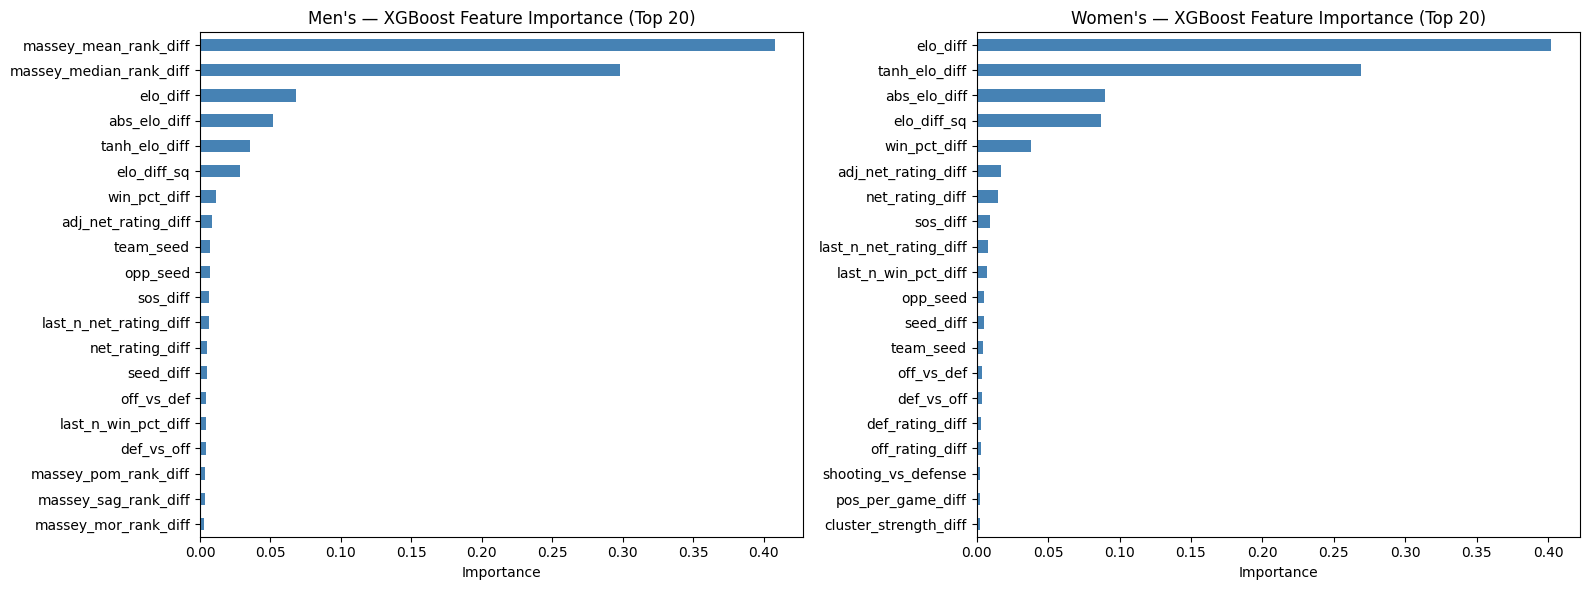

Men's top features:
massey_mean_rank_diff      0.407722
massey_median_rank_diff    0.298319
elo_diff                   0.068241
abs_elo_diff               0.051787
tanh_elo_diff              0.035543
elo_diff_sq                0.028637
win_pct_diff               0.011224
adj_net_rating_diff        0.008393
team_seed                  0.007371
opp_seed                   0.007342


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, ensemble, label in [(axes[0], m_ensemble, "Men's"), (axes[1], w_ensemble, "Women's")]:
    imps = get_feature_importances(ensemble)
    imps.head(20).sort_values().plot.barh(ax=ax, color='steelblue')
    ax.set_title(f'{label} — XGBoost Feature Importance (Top 20)')
    ax.set_xlabel('Importance')

plt.tight_layout()
plt.show()

print("Men's top features:")
print(get_feature_importances(m_ensemble).head(10).to_string())

## 5 · Generate Submission

In [12]:
submission = generate_combined_submission(
    sample_sub=sample_sub,
    mens_team_features=m_team_features,
    mens_ensemble=m_ensemble,
    womens_team_features=w_team_features,
    womens_ensemble=w_ensemble,
    year_2026_only=True,
)

print(submission.head(10).to_string(index=False))
print(f'\nTotal rows     : {len(submission):,}')
print(f'Pred range     : [{submission["Pred"].min():.4f}, {submission["Pred"].max():.4f}]')
print(f'Pred mean      : {submission["Pred"].mean():.4f}  (should be ~0.500)')
print(f'Pred std       : {submission["Pred"].std():.4f}')

            ID     Pred
2026_1101_1102 0.828474
2026_1101_1103 0.053309
2026_1101_1104 0.041060
2026_1101_1105 0.807931
2026_1101_1106 0.859727
2026_1101_1107 0.874826
2026_1101_1108 0.903894
2026_1101_1110 0.352478
2026_1101_1111 0.227307
2026_1101_1112 0.037257

Total rows     : 132,133
Pred range     : [0.0288, 0.9711]
Pred mean      : 0.4984  (should be ~0.500)
Pred std       : 0.3767


### 5a · Prediction Distribution

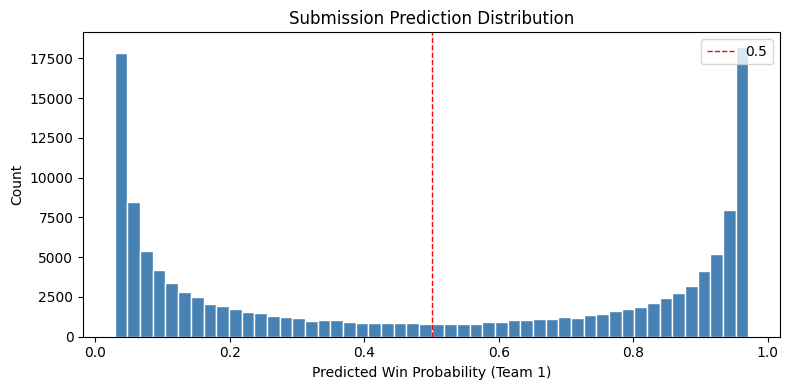

In [13]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(submission['Pred'], bins=50, edgecolor='white', color='steelblue')
ax.axvline(0.5, linestyle='--', color='red', linewidth=1, label='0.5')
ax.set_xlabel('Predicted Win Probability (Team 1)')
ax.set_ylabel('Count')
ax.set_title('Submission Prediction Distribution')
ax.legend()
plt.tight_layout()
plt.show()

### 5b · Save Submission

In [14]:
# os.makedirs(OUTPUT_DIR, exist_ok=True)
# output_path = os.path.join(OUTPUT_DIR, 'submission_2026.csv')
# submission.to_csv(output_path, index=False)
# print(f'Submission saved → {output_path}')

# ── CV Brier Score Summary ────────────────────────────────────────────────────
print('\n' + '='*45)
print('  BASELINE MODEL — CV Brier Score Summary')
print('='*45)
bs = fold_results['brier_score']
print(f'  Mean  : {bs.mean():.4f}  ← competition metric')
print(f'  Std   : {bs.std():.4f}')
print(f'  Best  : {bs.min():.4f}  (season {fold_results.loc[bs.idxmin(), "test_season"]})')
print(f'  Worst : {bs.max():.4f}  (season {fold_results.loc[bs.idxmax(), "test_season"]})')
print('='*45)


  BASELINE MODEL — CV Brier Score Summary
  Mean  : 0.1953  ← competition metric
  Std   : 0.0254
  Best  : 0.1471  (season 2025)
  Worst : 0.2404  (season 2011)
